<a href="https://colab.research.google.com/github/adamarsyadfaizin/PCVK26_10_Adam/blob/main/P2_PCVK_D1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
from google.colab import files
uploaded = files.upload()

Saving ktp.jpg to ktp (1).jpg


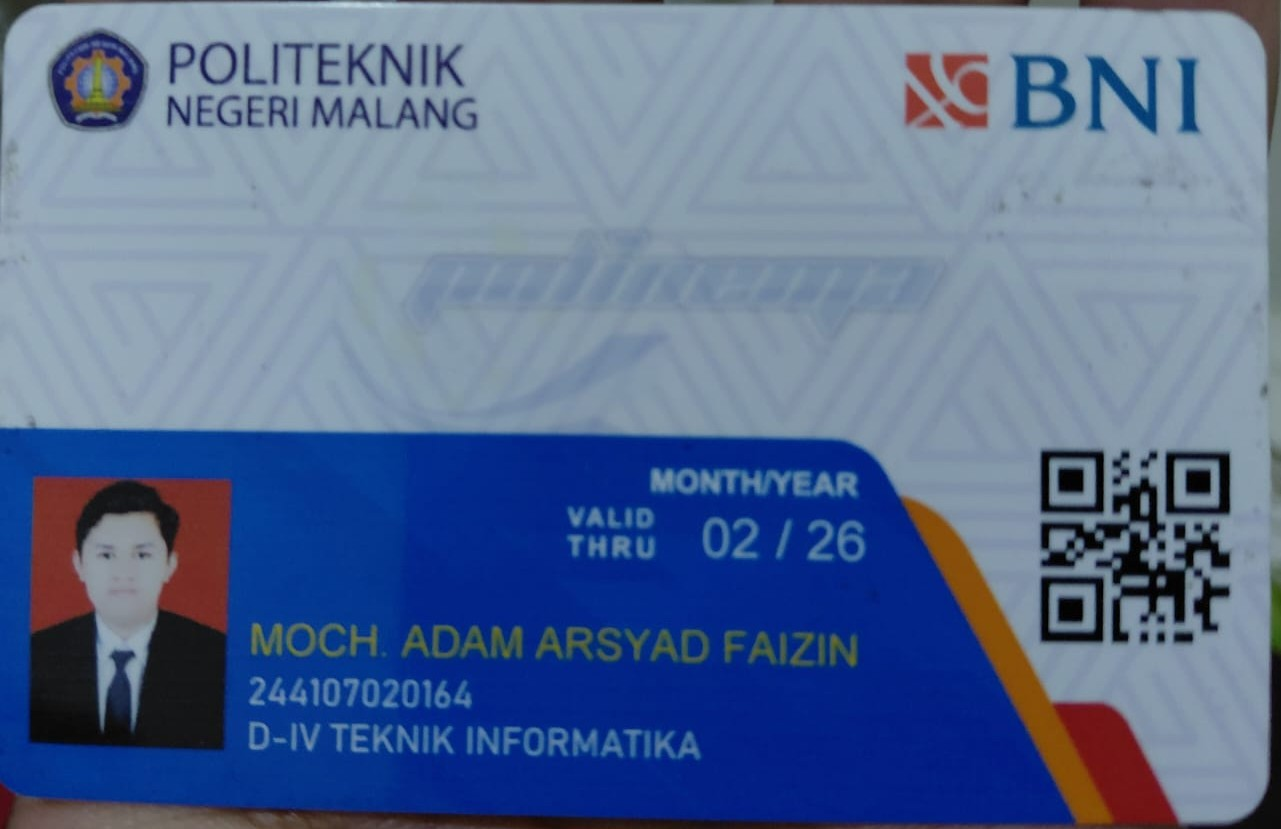

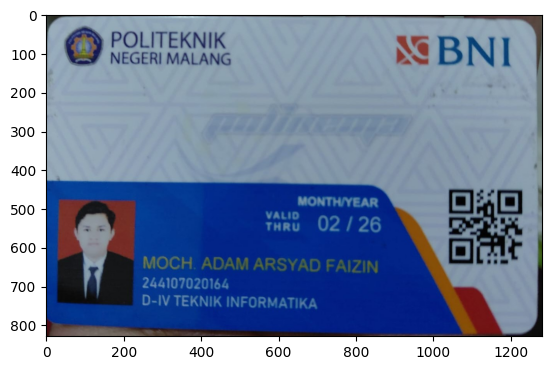

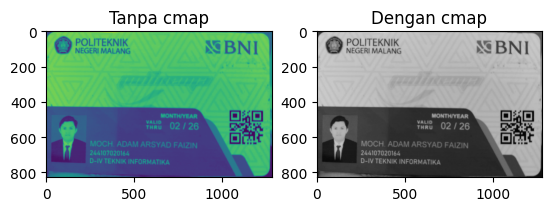

Resolusi gambar:  1281  x  829


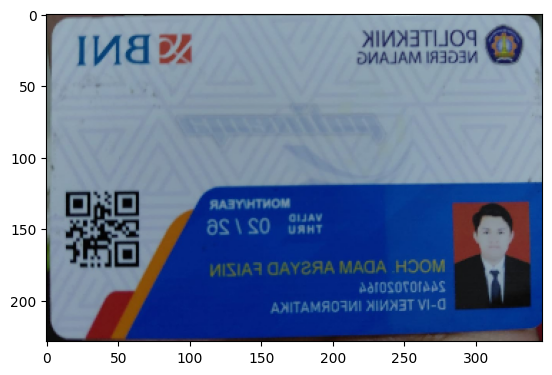

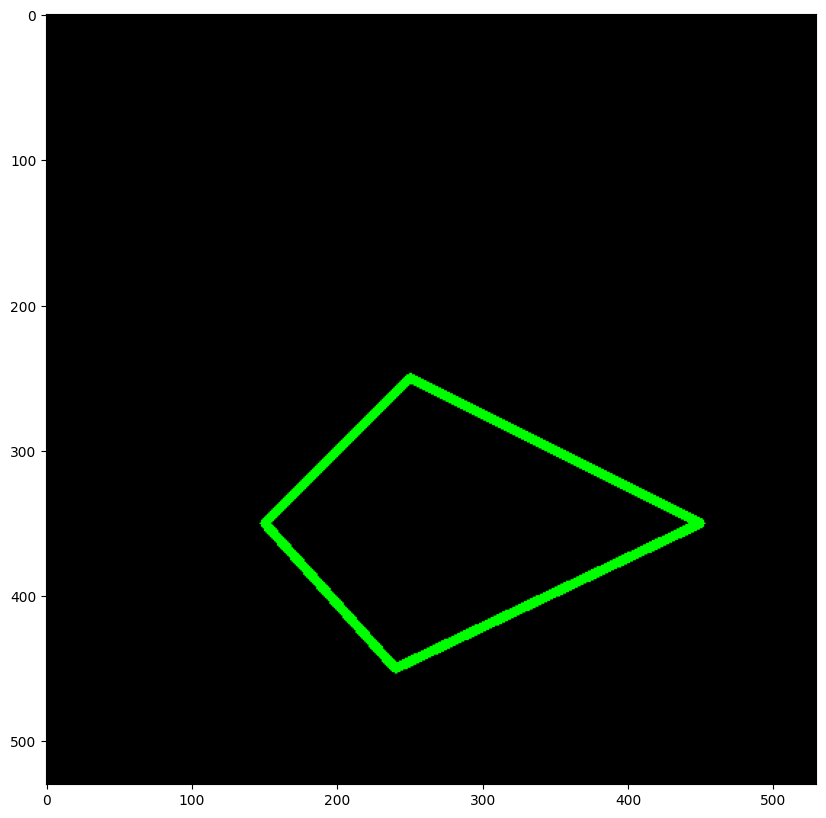

In [22]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread('ktp.jpg')
cv2_imshow(img)
plt.imshow(img)
img2 = cv.cvtColor(img,cv.COLOR_BGR2RGB)
plt.imshow(img2)
plt.imshow(cv.cvtColor(img,cv.COLOR_BGR2RGB))
plt.show()
img_gray = cv.imread('ktp.jpg', cv.IMREAD_GRAYSCALE)
plt.subplot(1,2,1)
plt.imshow(img_gray)
plt.title('Tanpa cmap')

plt.subplot(1,2,2)
plt.imshow(img_gray, cmap='gray')
plt.title('Dengan cmap')

plt.show()
plt.imshow(img_gray, cmap='magma')

imgRGB = cv.cvtColor(img,cv.COLOR_BGR2RGB)
img_output = cv.resize(imgRGB, (347,229))
plt.imshow(img_output)

imgFlip=cv.flip(img_output,1)
plt.imshow(imgFlip)
fig = plt.figure(figsize=(10,10))
ax=fig.add_subplot(1,1,1)
ax.imshow(imgFlip)

print("Resolusi gambar: ", img.shape[1], " x ", img.shape[0])

black_img = np.zeros(shape=(530,530,3),dtype=np.int16)
plt.imshow(black_img)

cv.rectangle(black_img,pt1=(290,0),pt2=(520,130),color=(0,0,255),thickness=10)
plt.imshow(black_img)

cv.rectangle(black_img,pt1=(250,250),pt2=(350,350),color=(255,0,0),thickness=15)
plt.imshow(black_img)

cv.circle(black_img,center=(150,150),radius=60,color=(0,255,0),thickness=8)
plt.imshow(black_img)

cv.circle(black_img,center=(400,400),radius=50,color=(0,255,0),thickness=-1)
cv.line(black_img,pt1=(0,0),pt2=(530,530),color=(255,255,255),thickness=5)
plt.imshow(black_img)

font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(black_img,text='PCVK is fun!',org=(10,500),fontFace=font,fontScale=2,color=(255,255,0),thickness=3,lineType=cv.LINE_AA)
plt.imshow(black_img)

black_img2=np.zeros(shape=(530,530,3),dtype=np.int32)
vertices = np.array([[150,350],[250,250],[450,350],[240,450]],np.int32)
vertices

pts = vertices.reshape((-1,1,2))
plt.imshow(black_img2)


cv.polylines(black_img2,[pts],isClosed=True,color=(0,255,0),thickness=5)
plt.imshow(black_img2)

PERTANYAAN PRAKTIKUM

1. Tampilkan satu citra bebas menggunakan cv2_imshow() dan plt.imshow() tanpa konversi warna apa pun. Mengapa hasilnya berbeda? Buktikan dengan mencetak nilai satu piksel yang sama dari kedua cara pembacaan tersebut.

Jawab : berbeda karena OpenCV menggunakan urutan kanal BGR (Blue, Green, Red), sedangkan Matplotlib menganggap array citra menggunakan urutan RGB (Red, Green, Blue)

Tampilan cv2_imshow:


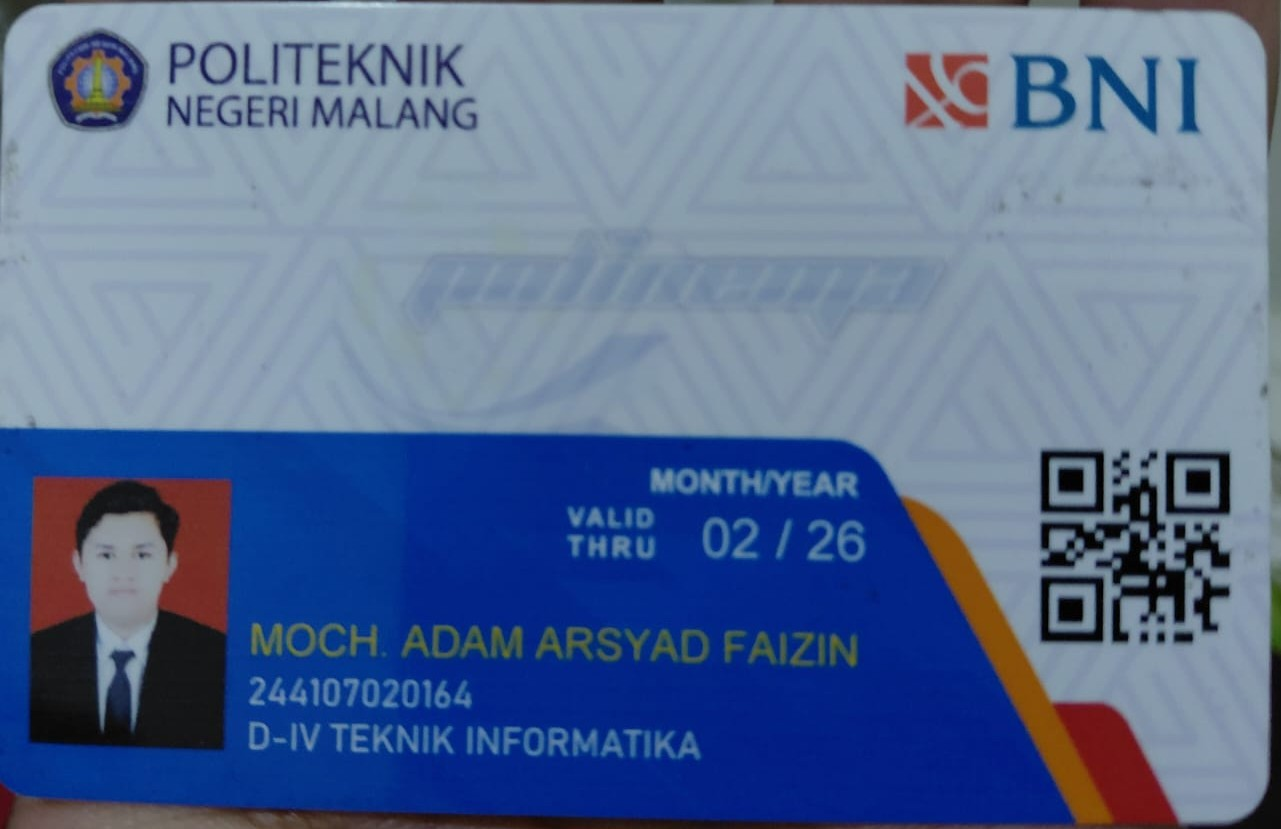

Tampilan plt.imshow:


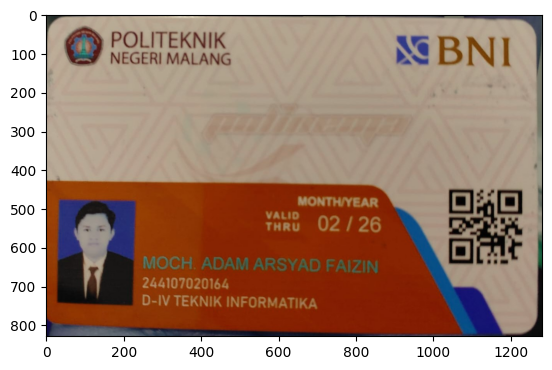

Koordinat piksel: (640, 414)
OpenCV (BGR) : [166 149 130]
Skimage (RGB): [130 149 166]


In [23]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt

img_cv = cv.imread('ktp.jpg')
img_sk = io.imread('ktp.jpg')
print("Tampilan cv2_imshow:")
cv2_imshow(img_cv)
print("Tampilan plt.imshow:")
plt.imshow(img_cv)
plt.show()

h, w = img_cv.shape[:2]
y = h // 2
x = w // 2

print("Koordinat piksel:", (x, y))
print("OpenCV (BGR) :", img_cv[y, x])
print("Skimage (RGB):", img_sk[y, x])

2. Buat kanvas hitam berukuran sama dengan tipe data int16 dan int32.
Bandingkan dtype, min(), max(), dan nbytes keduanya. Apakah tampilannya
berbeda? Apakah ukuran memorinya berbeda? Jelaskan alasannya.

Jawwab : Kanvas int16 membutuhkan 1.685.400 byte,
sedangkan int32 membutuhkan 3.370.800 byte

dtype: int16
min: 0
max: 0
nbytes: 1685400
dtype: int32
min: 0
max: 0
nbytes: 3370800


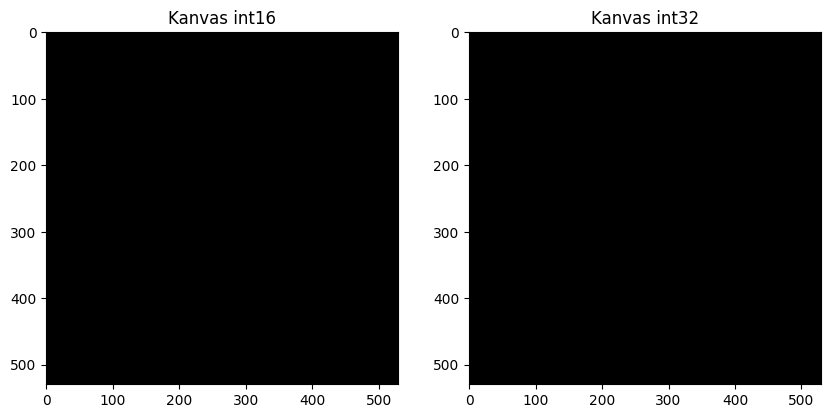

In [24]:
import numpy as np
import matplotlib.pyplot as plt

black_int16 = np.zeros((530, 530, 3), dtype=np.int16)
black_int32 = np.zeros((530, 530, 3), dtype=np.int32)
print("dtype:", black_int16.dtype)
print("min:", black_int16.min())
print("max:", black_int16.max())
print("nbytes:", black_int16.nbytes)
print("dtype:", black_int32.dtype)
print("min:", black_int32.min())
print("max:", black_int32.max())
print("nbytes:", black_int32.nbytes)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(black_int16)
plt.title("Kanvas int16")
plt.subplot(1, 2, 2)
plt.imshow(black_int32)
plt.title("Kanvas int32")
plt.show()

3. sebagai pengganti yang menampilkan citra langsung sebagai output pada cell notebook

4. Citra yang dibaca dengan skimage.io.imread ditampilkan berdampingan dengan hasil cv2.cvtColor img, cv2.COLOR_BGR2RGB atas citra yang sama. Manakah yang menampilkan warna sebenarnya, dan manakah yang kanalnya tertukar? Buktikan dengan nilai piksel, bukan dengan pengamatan visual saja.

Jawab : Citra yang dibaca langsung menggunakan skimage.io.imread menampilkan warna sebenarnya karena skimage menggunakan urutan kanal RGB.

Sebaliknya, hasil cv2.cvtColorimg, cv2.COLOR_BGR2RGB terhadap citra hasil skimage.io.imread memiliki kanal merah dan biru yang tertukar. Hal ini terjadi karena operasi COLOR_BGR2RGB menganggap citra masukan menggunakan urutan BGR, padahal citra dari skimage sudah berurutan RGB.

Bukti dapat dilihat dari nilai satu piksel. Jika nilai piksel asli adalah [R, G, B], setelah konversi tersebut urutannya menjadi [B, G, R]. Kanal hijau tetap berada di tengah, sedangkan kanal merah dan biru bertukar posis

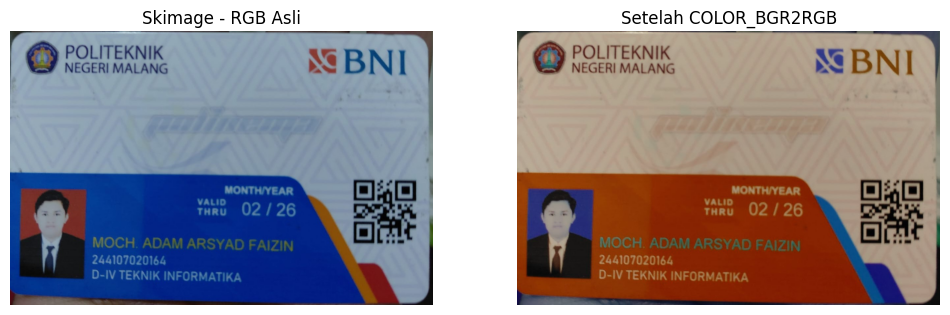

Koordinat piksel: (640, 414)
Skimage RGB       : [130 149 166]
Setelah cvtColor  : [166 149 130]


In [25]:
from skimage import io
import cv2 as cv
import matplotlib.pyplot as plt

img_sk = io.imread('ktp.jpg')
img_tukar = cv.cvtColor(img_sk, cv.COLOR_BGR2RGB)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_sk)
plt.title("Skimage - RGB Asli")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(img_tukar)
plt.title("Setelah COLOR_BGR2RGB")
plt.axis("off")
plt.show()
h, w = img_sk.shape[:2]
y = h // 2
x = w // 2
print("Koordinat piksel:", (x, y))
print("Skimage RGB       :", img_sk[y, x])
print("Setelah cvtColor  :", img_tukar[y, x])

5. Setelah citra ditampilkan dengan figsize yang jauh lebih besar, apakah nilai img.shape ikut berubah? Jelaskan perbedaan antara mengubah ukuran citra dan mengubah ukuran tampilan

Jawab : Nilai img.shape tidak berubah setelah citra ditampilkan menggunakan figsize yang lebih besar. Hal ini karena figsize hanya mengatur ukuran kanvas atau area tampilan pada Matplotlib, bukan mengubah jumlah piksel pada citra.

Mengubah ukuran tampilan menggunakan figsize hanya membuat gambar terlihat lebih besar atau lebih kecil pada output.

Sebaliknya, mengubah ukuran citra menggunakan cv2.resize benar-benar mengubah jumlah piksel sehingga nilai img.shape juga berubah

Shape sebelum ditampilkan: (829, 1281, 3)


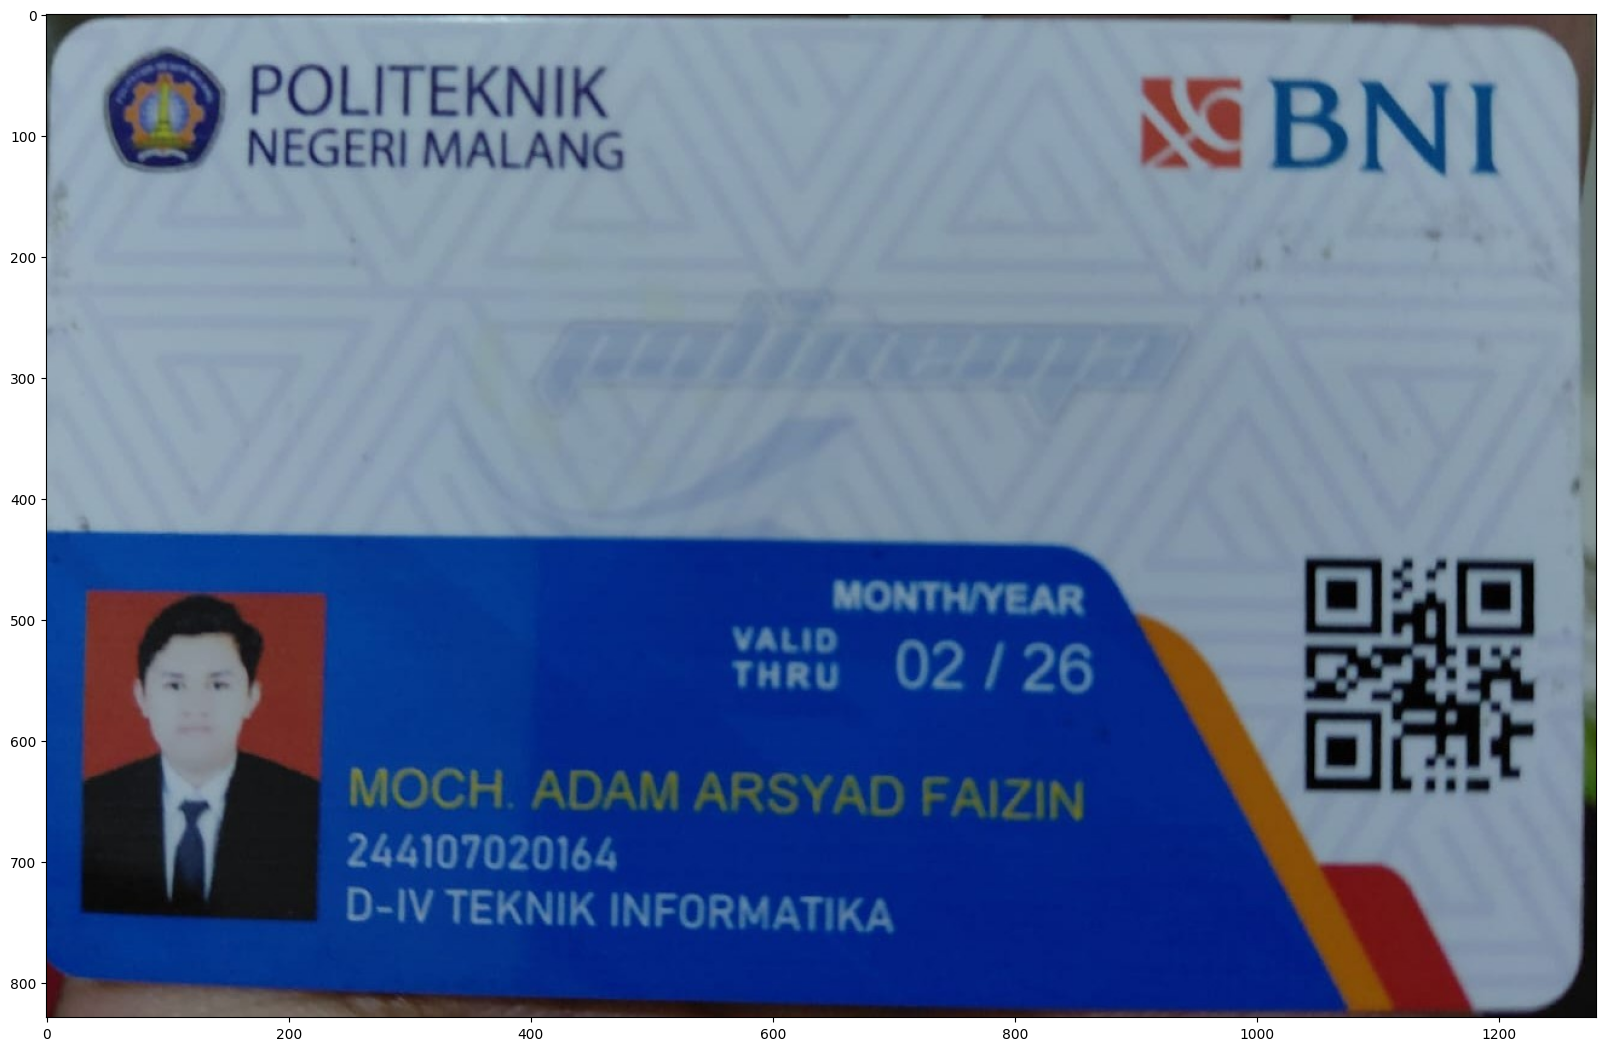

Shape setelah ditampilkan : (829, 1281, 3)


In [26]:
img = cv.imread('ktp.jpg')

print("Shape sebelum ditampilkan:", img.shape)
plt.figure(figsize=(20, 15))
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.show()
print("Shape setelah ditampilkan :", img.shape)

TUGAS PRAKTIKUM - Penerapan

1. Tampilkan citra hanya pada kombinasi kanal Merah-Biru dan kanal Hijau-Biru saja, dengan kanal yang tidak dipakai dinolkan. Susun keduanya berdampingan dalam satu figure yang diberi judul.

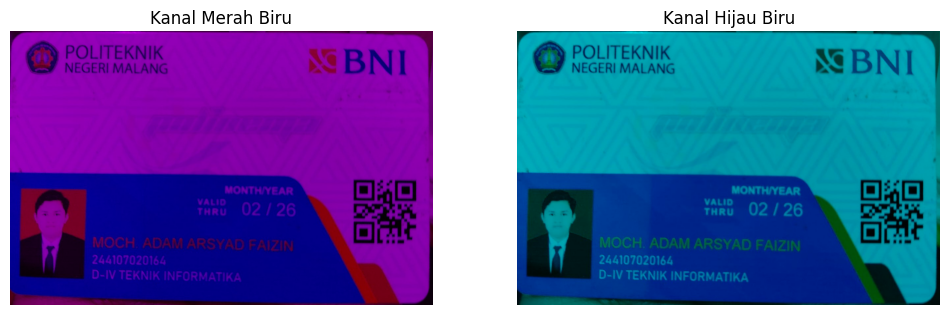

In [27]:
import cv2 as cv
import matplotlib.pyplot as plt

img = cv.imread('ktp.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img_rb = img_rgb.copy()
img_rb[:, :, 1] = 0
img_gb = img_rgb.copy()
img_gb[:, :, 0] = 0
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rb)
plt.title('Kanal Merah Biru')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_gb)
plt.title('Kanal Hijau Biru')
plt.axis('off')
plt.show()

2. Tampilkan citra dalam tiga bentuk pencerminan: vertikal, horizontal, dan keduanya, dalam satu figure berisi tiga subplot yang masing-masing diberi label.

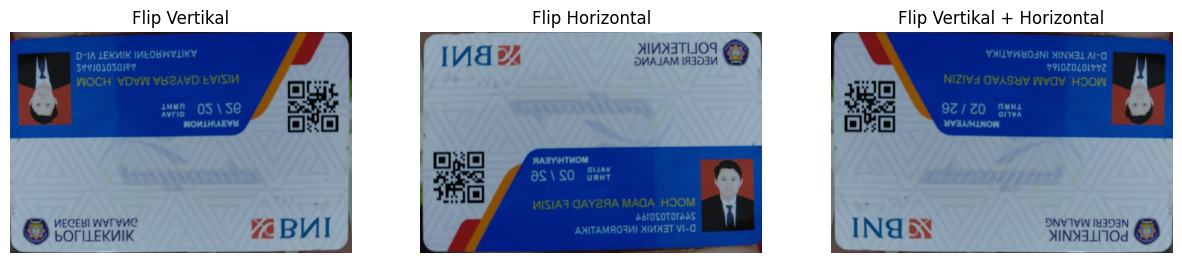

In [28]:
import cv2 as cv
import matplotlib.pyplot as plt

img = cv.imread('ktp.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
flip_vertikal = cv.flip(img_rgb, 0)
flip_horizontal = cv.flip(img_rgb, 1)
flip_keduanya = cv.flip(img_rgb, -1)
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(flip_vertikal)
plt.title('Flip Vertikal')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(flip_horizontal)
plt.title('Flip Horizontal')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(flip_keduanya)
plt.title('Flip Vertikal + Horizontal')
plt.axis('off')

plt.show()

3. Gambarkan sebuah rectangle dan sebuah circle pada bagian wajah / badan dari foto aktivitas Anda sendiri (bukan pasfoto), lalu tambahkan teks berisi nama Anda dengan pilihan font, ukuran, dan warna yang Anda tentukan sendiri.

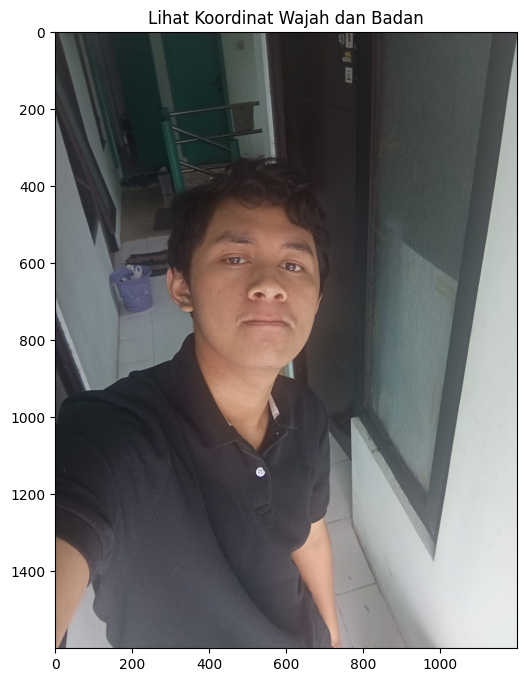

Ukuran gambar: (1600, 1200, 3)


In [29]:
img = cv.imread('foto_aktivitas.jpeg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.title('Lihat Koordinat Wajah dan Badan')
plt.show()

print("Ukuran gambar:", img.shape)

TUGAS PRAKTIKUM - Analisa

1. Rumuskan satu pertanyaan tentang citra digital yang dapat Anda jawab menggunakan kode dari modul ini. Contoh pertanyaan: berapa persen piksel pada foto KTM Anda yang lebih gelap dari nilai 100? apakah mengecilkan lalu membesarkan citra mengubah rata-rata intensitasnya? Tuliskan pertanyaan Anda, rancangan program, data hasilnya, dan kesimpulan Anda.


### Pertanyaan

Apakah pencerminan citra secara horizontal menggunakan `cv2.flip()`
mengubah nilai rata-rata intensitas citra?

### Rancangan Program

1. Membaca citra menggunakan `cv.imread()`.
2. Mengubah citra menjadi grayscale menggunakan `cv.cvtColor()`.
3. Menghitung rata-rata intensitas citra asli.
4. Melakukan pencerminan horizontal menggunakan `cv.flip(img, 1)`.
5. Menghitung rata-rata intensitas citra hasil pencerminan.
6. Membandingkan kedua nilai rata-rata intensitas.
7. Menampilkan citra asli dan citra hasil pencerminan.

Rata-rata intensitas citra asli : 107.28719269946109
Rata-rata intensitas hasil flip : 107.28719269946109
Selisih               : 0.0


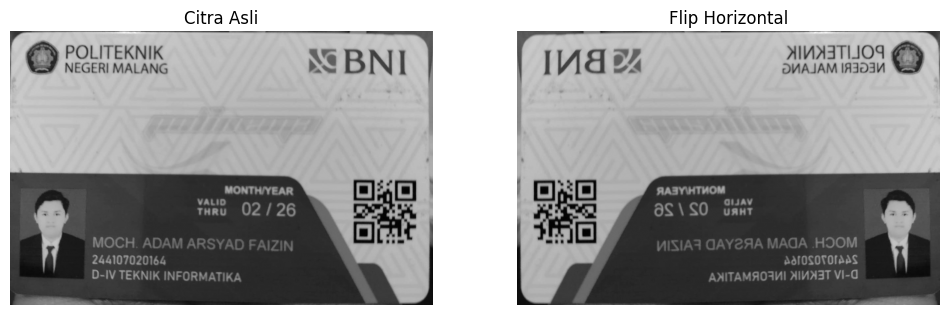

In [30]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread('ktp.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_flip = cv.flip(gray, 1)
mean_asli = np.mean(gray)
mean_flip = np.mean(gray_flip)
print("Rata-rata intensitas citra asli :", mean_asli)
print("Rata-rata intensitas hasil flip :", mean_flip)
print("Selisih               :", abs(mean_asli - mean_flip))
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title('Citra Asli')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(gray_flip, cmap='gray')
plt.title('Flip Horizontal')
plt.axis('off')

plt.show()

### Data Hasil

Berdasarkan hasil program diperoleh:

- Rata-rata intensitas citra asli = **107.28719269946109**
- Rata-rata intensitas citra hasil pencerminan horizontal = **107.28719269946109**
- Selisih rata-rata intensitas = **0**

Secara visual, posisi piksel pada citra berubah karena mengalami pencerminan
horizontal, tetapi nilai rata-rata intensitas citra tetap sama.

### Kesimpulan

Pencerminan horizontal menggunakan `cv2.flip()` tidak mengubah rata-rata
intensitas citra. Hal ini terjadi karena proses pencerminan hanya mengubah
posisi atau susunan piksel, sedangkan nilai intensitas setiap piksel tetap sama.

Dengan demikian, meskipun tampilan citra berubah karena sisi kiri dan kanan
bertukar posisi, kumpulan nilai pikselnya tetap sama sehingga rata-rata
intensitas sebelum dan sesudah pencerminan juga sama.

TUGAS PRAKTIKUM - Aplikasi


Pada bagian ini, Anda hanya diperbolehkan memakai fungsi yang telah dipelajari pada modul ini: pembacaan berkas, pengirisan, cv2.resize, cv2.flip, cv2.cvtColor, fungsi penggambaran OpenCV, serta pembuatan kanvas dengan NumPy. Selain itu, program harus bersifat adaptif, dimana setiap ukuran, posisi, atau ketebalan harus dihitung dari ukuran citra masukan, bukan ditulis sebagai angka tetap pada kode program.
Studi Kasus 1: Panitia sebuah kegiatan perlu membubuhkan label identitas pada ratusan foto dokumentasi. Foto berasal dari beberapa kamera dan ponsel, sehingga ukurannya bermacam-macam. Label harus terlihat seimbang pada semua foto tanpa disetel satu per satu. Fungsi yang sama dikenakan pada dua citra berbeda ukuran. Tinggi bar dan ukuran huruf ikut menyesuaikan, sehingga proporsinya tetap sama. Silakan melakukan akuisisi data sendiri, setiap anak harus menggunakan image yang berbeda-beda






Studi Kasus 2: Marketplace seperti Tokopedia dan Shopee menampilkan foto produk dalam bingkai persegi 1:1. Foto penjual yang berukuran potrait atau lanskap akan terpotong atau terlihat tidak proporsional bila diunggah begitu saja. Bangun program yang mengubah foto berukuran apa pun menjadi thumbnail persegi tanpa mengubah rasio aslinya, dengan sisa ruang diisi kanvas berwarna. Dalam hal ini, rasio asli tetap terjaga, citra terpasang tepat di tengah kanvas, tambahkan logo nama toko berukuran proporsional pada gambar.





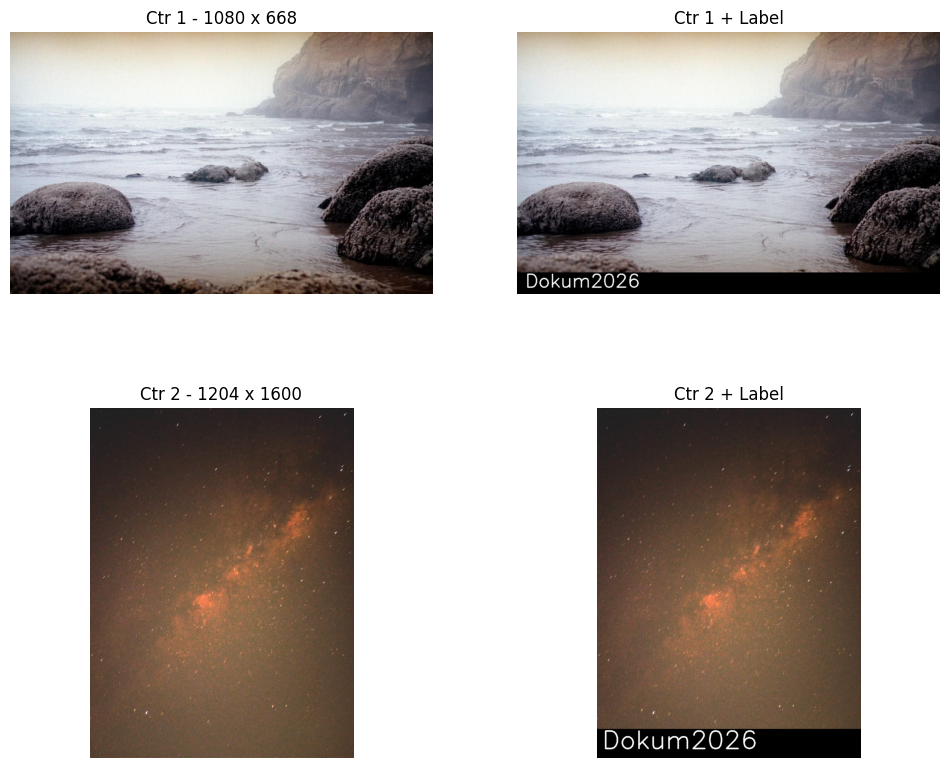

In [31]:
import cv2 as cv
import matplotlib.pyplot as plt

img1 = cv.imread('foto1.jpg')
img2 = cv.imread('foto2.jpeg')

def tambah_label(img, teks):
    hasil = img.copy()
    h, w = hasil.shape[:2]
    bar_h = h // 12
    thickness = bar_h // 25
    if thickness < 1:
        thickness = 1
    font_scale = bar_h / 35
    cv.rectangle(
        hasil,
        (0, h - bar_h),
        (w, h),
        (0, 0, 0),
        -1
    )
    x_text = w // 50
    y_text = h - bar_h // 3
    cv.putText(
        hasil,
        teks,
        (x_text, y_text),
        cv.FONT_HERSHEY_SIMPLEX,
        font_scale,
        (255, 255, 255),
        thickness,
        cv.LINE_AA
    )
    return hasil

hasil1 = tambah_label(img1, 'Dokum2026')
hasil2 = tambah_label(img2, 'Dokum2026')
hasil1_rgb = cv.cvtColor(hasil1, cv.COLOR_BGR2RGB)
hasil2_rgb = cv.cvtColor(hasil2, cv.COLOR_BGR2RGB)
img1_rgb = cv.cvtColor(img1, cv.COLOR_BGR2RGB)
img2_rgb = cv.cvtColor(img2, cv.COLOR_BGR2RGB)

plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
plt.imshow(img1_rgb)
plt.title('Ctr 1 - ' + str(img1.shape[1]) + ' x ' + str(img1.shape[0]))
plt.axis('off')
plt.subplot(2, 2, 2)
plt.imshow(hasil1_rgb)
plt.title('Ctr 1 + Label')
plt.axis('off')
plt.subplot(2, 2, 3)
plt.imshow(img2_rgb)
plt.title('Ctr 2 - ' + str(img2.shape[1]) + ' x ' + str(img2.shape[0]))
plt.axis('off')
plt.subplot(2, 2, 4)
plt.imshow(hasil2_rgb)
plt.title('Ctr 2 + Label')
plt.axis('off')

plt.show()

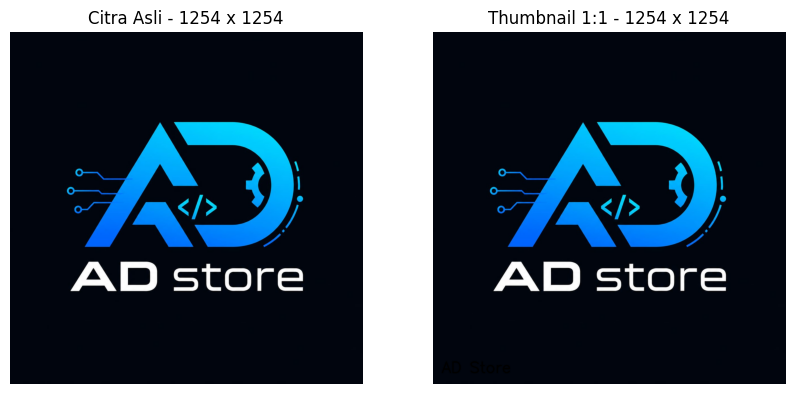

In [32]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def buat_thumbnail(img, nama_toko):
    h, w = img.shape[:2]
    if w > h:
        ukuran = w
    else:
        ukuran = h
    if w > h:
        new_w = ukuran
        new_h = (h * ukuran) // w
    else:
        new_h = ukuran
        new_w = (w * ukuran) // h
    resized = cv.resize(
        img,
        (new_w, new_h),
        interpolation=cv.INTER_AREA
    )
    canvas = np.full(
        (ukuran, ukuran, 3),
        255,
        dtype=np.uint8
    )
    x = (ukuran - new_w) // 2
    y = (ukuran - new_h) // 2
    canvas[
        y:y + new_h,
        x:x + new_w
    ] = resized
    font_scale = ukuran / 700

    thickness = ukuran // 300
    if thickness < 1:
        thickness = 1
    text_x = ukuran // 40
    text_y = ukuran - ukuran // 30
    cv.putText(
        canvas,
        nama_toko,
        (text_x, text_y),
        cv.FONT_HERSHEY_SIMPLEX,
        font_scale,
        (0, 0, 0),
        thickness,
        cv.LINE_AA
    )
    return canvas
img = cv.imread('produk.jpeg')
thumbnail = buat_thumbnail(img, 'AD Store')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
thumbnail_rgb = cv.cvtColor(thumbnail, cv.COLOR_BGR2RGB)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title(
    'Citra Asli - ' +
    str(img.shape[1]) +
    ' x ' +
    str(img.shape[0])
)
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(thumbnail_rgb)
plt.title(
    'Thumbnail 1:1 - ' +
    str(thumbnail.shape[1]) +
    ' x ' +
    str(thumbnail.shape[0])
)
plt.axis('off')

plt.show()